In [ ]:
import pandas as pd
import numpy as np
import re
import string
import json
import tensorflow as tf
import multiprocessing as mp
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Text Analysis
import nltk
try:
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Yggdrasil Decision Forests
import ydf

print("All libraries imported successfully!")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class EnhancedSMSSpamFilter:
    """
    Enhanced SMS Spam Filter with TF-IDF, Sentiment Analysis, and Spellchecking
    """

    def custom_standardization(self, input_data):
        with open('/content/drive/MyDrive/colab_mounted_files/stopwords-tl.json', 'r') as f:
            tl_stopwords = json.load(f)

        with open('/content/drive/MyDrive/colab_mounted_files/stopwords-en.json', 'r') as f:
            eng_stopwords = json.load(f)

        all_stopwords_set = set(tl_stopwords + eng_stopwords)

        text = tf.strings.lower(input_data)

        # --- START: Conditional Leet Speak Normalization ---

        # 1. Handle specific, known exceptions first
        # We use \b (word boundary) to ensure we only match 'unl!' as a whole word
        text = tf.strings.regex_replace(text, r'\bunl!\b', 'unli')

        # 2. Define the character map for normalization
        leet_char_map = {
            '0': 'o',
            '@': 'a',
            '3': 'e',
            '5': 's',
            '1': 'i',
            '$': 's',
            '!': 'i',
            '6': 'g',
            '4': 'a'
        }

        # 3. Apply normalization using your conditional logic
        for char, replacement in leet_char_map.items():
            # Must escape the char in case it's a regex special char (like '$')
            safe_char = re.escape(char)

            # Logic 1: "Enclosed by letter"
            # Pattern: ([a-z]) + CHAR + ([a-z])
            # Replace: \1 (group 1) + REPLACEMENT + \2 (group 2)
            # Example: m3s -> mes, lph0n -> lphon
            enclosed_pattern = r'([a-z])' + safe_char + r'([a-z])'
            replacement_pattern = r'\1' + replacement + r'\2'
            text = tf.strings.regex_replace(text, enclosed_pattern, replacement_pattern)

            # Logic 2: "Ends with a number/symbol"
            # Pattern: ([a-z]) + CHAR + \b (word boundary)
            # Replace: \1 (group 1) + REPLACEMENT
            # Example: b0nu5 -> bonus, nanal0 -> nanalo
            ends_with_pattern = r'([a-z])' + safe_char + r'\b'
            replacement_pattern = r'\1' + replacement
            text = tf.strings.regex_replace(text, ends_with_pattern, replacement_pattern)

            # (Optional) Logic 3: "Starts with a number/symbol"
            # Pattern: \b (word boundary) + CHAR + ([a-z])
            # Replace: REPLACEMENT + \1 (group 1)
            # Example: f4cebook -> facebook
            starts_with_pattern = r'\b' + safe_char + r'([a-z])'
            replacement_pattern = replacement + r'\1'
            text = tf.strings.regex_replace(text, starts_with_pattern, replacement_pattern)

            # --- END: Leet Speak Normalization ---

        # Now, strip all remaining punctuation
        lowercased_and_stripped = tf.strings.regex_replace(text, '[%s]' % re.escape(string.punctuation), '')

        # Continue with stopword removal
        stopword_pattern = r'\b(' + '|'.join(re.escape(s) for s in all_stopwords_set) + r')\b'
        no_stopwords = tf.strings.regex_replace(lowercased_and_stripped, stopword_pattern, ' ')

        # Clean up extra whitespace
        clean_text = tf.strings.regex_replace(no_stopwords, r'\s+', ' ')

        return clean_text

    def __init__(self, tfidf_features=100):

        self.model = None

        self.tfidf_vectorizer = tf.keras.layers.TextVectorization(
            max_tokens=tfidf_features,
            output_mode="tf_idf",
            ngrams=1,
            standardize=self.custom_standardization
        )
        self.scaler = StandardScaler()
        self.sia = SentimentIntensityAnalyzer()

        # Feature names for later analysis
        self.feature_names = []

        # Spam indicators
        self.spam_words = ['free', 'win', 'winner', 'cash', 'prize', 'claim',
                           'urgent', 'offer', 'guaranteed', 'credit', 'loan',
                           'congrats', 'congratulations', 'click', 'buy', 'now',
                           'limited', 'act', 'call', 'text', 'reply', 'stop',
                           'libre', 'panalo', 'manalo', 'nanalo', 'premyo', 'swerte',
                           'click here', 'napanalunan', 'paclaim', 'xyz', 'spin',
                           'lucky', 'redeem', 'bonuses', 'vip', 'reward', 'jackpot',
                            'b0nus', 'cH@NC3', 'b0nu5', 'lph0ne', 's@s@kyan', 'f@cebook',
                           'mess3nger', 'nanal0', 'mess@ge', 'sc@tter', 'm3ssag3', 'unl!',
                           'pumaldo', 'paldo', 'm3ssage', 'm3ssager', 'sir/maam'
                          ]

        self.money_words = ['$', 'dollar', 'pound', 'cash', 'money',
                           'price', 'cost', 'fee', 'cheap', 'free', 'prize',
                           'p', 'php', 'Ã¢', 'Â±', 'pera', 'bonus', 'bayad',
                            'diskwento', 'libre', 'peso'
                           ]

        self.urgency_words = ['urgent', 'hurry', 'now', 'immediately', 'instant',
                            'act', 'limited', 'expires', 'deadline', 'today',
                            'ngayon', 'confirm today', 'within', 'ngayun', 'ngaun',
                            'n0w'
                            ]

    def extract_base_features(self, messages):
        """
        Extract comprehensive handcrafted features from SMS messages.
        """
        features = pd.DataFrame()

        features['has_dti_code'] = messages.str.contains(
            r'DTI\d{6}',
            case=False,
            regex=True
        ).astype(int)

        features['has_ref_no'] = messages.str.contains(
            r'ref\.?\s?no\.?\s?(\d{13}|[0-9a-f]{12})',
            case=False,
            regex=True
        ).astype(int)

        # Basic text statistics
        features['msg_length'] = messages.str.len()
        features['word_count'] = messages.str.split().str.len()
        features['avg_word_length'] = messages.apply(
            lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
        )

        features['num_digits'] = messages.str.findall(r'\d').str.len()
        features['digit_ratio'] = features['num_digits'] / (features['msg_length'] + 1)
        features['num_spaces'] = messages.str.count(' ')
        features['space_ratio'] = features['num_spaces'] / (features['msg_length'] + 1)

        # Punctuation features
        features['total_punctuation'] = messages.apply(
            lambda x: sum(1 for char in x if char in string.punctuation)
        )
        features['punctuation_ratio'] = features['total_punctuation'] / (features['msg_length'] + 1)

        # Special character features
        features['num_special_chars'] = messages.apply(
            lambda x: sum(1 for char in x if not char.isalnum() and not char.isspace())
        )
        features['special_char_ratio'] = features['num_special_chars'] / (features['msg_length'] + 1)

        # Money patterns
        features['has_money_pattern'] = messages.str.contains(
            r'\b(p\d+k?|\d+[pk])\b', case=False, regex=True
        ).astype(int)
        features['num_money_patterns'] = messages.str.findall(
            r'\b(p\d+k?|\d+[pk])\b'
        ).str.len()

        # Shorten URL detection
        features['has_url'] = messages.str.contains(
            r'http[s]?://|www\.|bit\.ly|tinyurl', case=False, regex=True
        ).astype(int)

        features['has_phone'] = messages.str.contains(
          r'\b\d{10,15}\b|\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b', regex=True
        ).astype(int)

        features['has_email'] = messages.str.contains(
            r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', regex=True
        ).astype(int)

        # Spam keyword features
        features['spam_word_count'] = messages.apply(
            lambda x: sum(1 for word in x.lower().split() if word in self.spam_words)
        )
        features['spam_word_ratio'] = features['spam_word_count'] / (features['word_count'] + 1)

        # Money-related features
        features['money_mentions'] = messages.apply(
            lambda x: sum(1 for word in self.money_words if word.lower() in x.lower())
        )
        features['urgency_score'] = messages.apply(
            lambda x: sum(1 for word in x.lower().split() if word in self.urgency_words)
        )

        features['has_price'] = messages.str.contains(
            r'\$\d+|p\d+|php\d+|\d+php\|\d+p|\d+k|\d+\s*(dollar|pound|euro|usd|gbp|peso|php|p|k)', case=False, regex=True
        ).astype(int)

        # Consecutive capitals and repeating characters
        features['has_repeating_chars'] = messages.str.contains(
            r'(.)\1{2,}', regex=True
        ).astype(int)

        # Call-to-action detection
        features['has_cta'] = messages.str.contains(
            r'\b(call|text|reply|click|visit|stop|subscribe|unsubscribe|confirm|msg|message|messge|msge)\b',
            case=False, regex=True
        ).astype(int)

        # Alphanumeric features
        features['num_alphanumeric'] = messages.apply(
            lambda x: sum(1 for char in x if char.isalnum())
        )
        features['alphanumeric_ratio'] = features['num_alphanumeric'] / (features['msg_length'] + 1)

        # Sentence count
        features['sentence_count'] = messages.apply(
            lambda x: len(re.findall(r'[.!?]+', x)) + 1
        )

        # Average sentence length
        features['avg_sentence_length'] = features['word_count'] / features['sentence_count']

        # Time pressure indicators
        features['has_time_limit'] = messages.str.contains(
            r'\b(\d+\s*(hours?|hrs?|minutes?|mins?|days?|weeks?))|today|tonight|tomorrow\b',
            case=False, regex=True
        ).astype(int)

        features['has_sms_code'] = messages.str.contains(
            r'\b[A-Z]{4,10}\b\s+to\s+\d{4,6}', regex=True
        ).astype(int)
        return features

    def extract_sentiment_features(self, messages):
        """
        Extract sentiment features using TextBlob and VADER
        """
        features = pd.DataFrame()

        # VADER sentiment analysis
        print("Extracting VADER sentiment features...")
        vader_scores = messages.apply(lambda x: self.sia.polarity_scores(x))
        features['vader_positive'] = vader_scores.apply(lambda x: x['pos'])
        features['vader_negative'] = vader_scores.apply(lambda x: x['neg'])
        features['vader_neutral'] = vader_scores.apply(lambda x: x['neu'])
        features['vader_compound'] = vader_scores.apply(lambda x: x['compound'])

        # Emotional intensity features
        features['emotion_range'] = features['vader_positive'] - features['vader_negative']
        features['emotion_intensity'] = features['vader_positive'] + features['vader_negative']

        return features

    def extract_tfidf_features(self, messages, fit=True):
        """
        Extract TF-IDF features using TextVectorization
        """
        print("Extracting TF-IDF features...")
        # Ensure messages is a TensorFlow Dataset or a list/array of strings
        messages_tf = tf.constant(messages.tolist()) # Convert pandas Series to list, then to tf.constant

        if fit:
            self.tfidf_vectorizer.adapt(messages_tf) # Use adapt for fitting
        tfidf_matrix = self.tfidf_vectorizer(messages_tf) # Use call for transformation

        # Convert SparseTensor to dense numpy array, then to DataFrame
        tfidf_matrix_dense = tfidf_matrix.numpy()

        vocab = self.tfidf_vectorizer.get_vocabulary()

        # Get feature names (vocabulary) after adapting
        feature_names = [f'tfidf_{word}' for word in vocab]

        tfidf_df = pd.DataFrame(
            tfidf_matrix_dense,
            columns=feature_names
        )

        # Drop the tfidf_[UNK] column if it exists
        # if 'tfidf_[UNK]' in tfidf_df.columns:
        #     tfidf_df = tfidf_df.drop(columns=['tfidf_[UNK]'])

        return tfidf_df

    def prepare_features(self, messages, fit_tfidf=True):
        """
        Combine all feature extraction methods with spellchecking
        """
        print("Preparing features...")

        # Extract base features (before spellcheck)
        base_features = self.extract_base_features(messages)

        # Extract sentiment features (on corrected text)
        sentiment_features = self.extract_sentiment_features(messages)

        # Extract TF-IDF features (on corrected text)
        tfidf_features = self.extract_tfidf_features(messages, fit=fit_tfidf)

        # Combine all features
        all_features = pd.concat([
            base_features.reset_index(drop=True),
            sentiment_features.reset_index(drop=True),
            tfidf_features.reset_index(drop=True)
        ], axis=1)

        # Store feature names
        if fit_tfidf:
            self.feature_names = all_features.columns.tolist()

        print(f"Total features extracted: {all_features.shape[1]}")
        print(f"  - Base features: {base_features.shape[1]}")
        print(f"  - Sentiment features: {sentiment_features.shape[1]}")
        print(f"  - TF-IDF features: {tfidf_features.shape[1]}")

        return all_features

    def train(self, X_train, y_train, max_depth=16, num_trees=100,
              balance_weight=False, verbose=True):
        """
        Train the Random Forest model using Yggdrasil Decision Forests
        """
        print("\n=== Training Model ===")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

        # Combine features and labels for YDF
        train_df = X_train_scaled.copy()
        train_df['label'] = y_train.values

        templates = ydf.RandomForestLearner.hyperparameter_templates()
        benchmark_rank1v1 = templates['benchmark_rank1v1']

        # Configure the learner
        learner = ydf.RandomForestLearner(
            label='label',
            num_trees=num_trees,
            max_depth=max_depth,
            compute_oob_variable_importances=True,
            compute_oob_performances=True,
            num_threads=None,
            task=ydf.Task.CLASSIFICATION,
            **benchmark_rank1v1,
            random_seed=42
        )

        # Train the model
        self.model = learner.train(train_df)

        if verbose:
            print(f"✓ Model trained successfully!")
            print(f"  Number of trees: {num_trees}")
            print(f"  Max depth: {max_depth}")

        return self.model

    def predict(self, X):
        """
        Make predictions on new data
        """
        if self.model is None:
            raise ValueError("Model not trained yet!")

        X_scaled = self.scaler.transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
        predictions = self.model.predict(X_scaled)
        return (predictions >= 0.5).astype(int)

    def predict_proba(self, X):
        """
        Get prediction probabilities
        """
        if self.model is None:
            raise ValueError("Model not trained yet!")

        X_scaled = self.scaler.transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

        return self.model.predict(X_scaled)

    def get_feature_importance(self, top_n=25):
        if self.model is None:
            raise ValueError("Model not trained yet!")

        importances = self.model.variable_importances()

        importance_df = pd.DataFrame([
            {'feature': name, 'importance': score}
            for name, score in list(importances.items())[:top_n]
        ])

        return importance_df

In [ ]:
def load_and_prepare_data(file_path):
    """
    Load CSV file and prepare data for training
    """
    print(f"Loading data from: {file_path}")

    # Load the CSV file
    df = pd.read_csv(file_path)

    print(f"Data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Basic data info
    print(f"\nClass distribution:")
    print(f"  Spam (1): {(df['label'] == 1).sum()} messages")
    print(f"  Ham (0): {(df['label'] == 0).sum()} messages")

    # Check for missing values
    missing = df.isnull().sum()
    if missing.any():
        print(f"\nMissing values:")
        print(missing[missing > 0])

    return df

def evaluate_model(model, X_test, y_test, show_plots=True):
    """
    Comprehensive model evaluation with visualizations
    """
    print("\n=== Model Evaluation ===\n")

    # Get predictions and probabilities
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    # Classification report
    print("Classification Report:")
    print("=" * 50)
    print(classification_report(y_test, predictions,
                               target_names=['Ham (0)', 'Spam (1)'],
                               digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    # Calculate metrics
    accuracy = np.mean(predictions == y_test)

    print(f"Overall Accuracy: {accuracy:.4f}")

    if show_plots:
        # Create visualization subplots
        fig, axes = plt.subplots(1, 1, figsize=(8, 6))

        # Plot 1: Confusion Matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
                   xticklabels=['Ham', 'Spam'],
                   yticklabels=['Ham', 'Spam'],
                   ax=axes)
        axes.set_title('Confusion Matrix')
        axes.set_ylabel('True Label')
        axes.set_xlabel('Predicted Label')

        plt.tight_layout()
        plt.show()

    return {
        'accuracy': accuracy,
        'confusion_matrix': cm,
    }
import matplotlib.cm as cm
def plot_feature_importance(spam_filter, importance_type="MEAN_DECREASE_IN_ACCURACY", top_n=10):
    """
    Plot top feature importances for a YDF RandomForestModel.
    """
    var_imps = spam_filter.model.variable_importances()
    print("Available importance types:", var_imps.keys())

    if importance_type not in var_imps:
        raise ValueError(f"Importance type '{importance_type}' not found. Use one from {list(var_imps.keys())}")

    imp_list = var_imps[importance_type]
    if not imp_list:
        print("No importances returned. Check if compute_oob_variable_importances was enabled.")
        return pd.DataFrame()

    # Convert to DataFrame
    importance_df = pd.DataFrame(imp_list, columns=['importance', 'feature'])

    # Ensure importance values are numeric
    importance_df["importance"] = pd.to_numeric(importance_df["importance"], errors="coerce")

    # Sort and take top_n
    importance_df = importance_df.sort_values(by="importance", ascending=False).head(top_n)

    # Use YlGn colormap
    cmap = cm.get_cmap('YlGn')
    norm = plt.Normalize(importance_df['importance'].min() * 0.1, importance_df['importance'].max())
    colors = cmap(norm(importance_df['importance'].values))

    # Plot
    plt.figure(figsize=(10, 8_))
    plt.barh(importance_df["feature"], importance_df["importance"], color=colors)
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances ({importance_type})")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return importance_df

In [ ]:
def train_spam_filter(csv_file_path, test_size=0.2, num_trees=100, max_depth=16):
    global X_train, X_test, y_train, y_test
    """
    Main training pipeline

    Parameters:
    -----------
    csv_file_path : str
        Path to your CSV file with columns: sender, text, label
    test_size : float
        Proportion of data to use for testing (default: 0.2)
    num_trees : int
        Number of trees in the random forest (default: 100)
    max_depth : int
        Maximum depth of trees (default: 16)
    """

    # Load data
    df = load_and_prepare_data(csv_file_path)

    # Initialize the filter
    print("\nInitializing Enhanced SMS Spam Filter with Spellchecker...")
    spam_filter = EnhancedSMSSpamFilter(tfidf_features=3000)

    # Extract features from text
    print("\nExtracting features from messages...")
    X = spam_filter.prepare_features(df['text'], fit_tfidf=True)
    y = df['label']

    # Split the data
    print("\nSplitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    print(f"Training set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")

    # Train the model
    spam_filter.train(X_train, y_train, num_trees=num_trees, max_depth=max_depth)

    # Evaluate the model
    results = evaluate_model(spam_filter, X_test, y_test)

    # Plot feature importance
    print("\n=== Feature Importance Analysis ===")
    importance_df = plot_feature_importance(spam_filter, top_n=20)

    return spam_filter, results, importance_df

def predict_new_messages(spam_filter, messages):
    """
    Predict whether new messages are spam or ham

    Parameters:
    -----------
    spam_filter : EnhancedSMSSpamFilter
        Trained spam filter model
    messages : list or pd.Series
        New messages to classify
    """
    if isinstance(messages, str):
        messages = [messages]

    messages_df = pd.DataFrame({'text': messages})

    # Extract features (don't fit TF-IDF, use existing vocabulary)
    X_new = spam_filter.prepare_features(messages_df['text'], fit_tfidf=False)

    # Make predictions
    predictions = spam_filter.predict(X_new)
    probabilities = spam_filter.predict_proba(X_new)

    # Create results dataframe
    results_df = pd.DataFrame({
        'message': messages,
        'prediction': ['SPAM' if p == 1 else 'HAM' for p in predictions],
        'spam_probability': probabilities,
        'confidence': [max(p, 1-p) for p in probabilities]
    })

    # Display results
    print("\n=== Prediction Results ===\n")
    for idx, row in results_df.iterrows():
        print(f"Message {idx+1}:")
        print(f"  Text: \"{row['message'][:100]}...\"" if len(row['message']) > 100 else f"  Text: \"{row['message']}\"")
        print(f"  Prediction: {row['prediction']}")
        print(f"  Spam Probability: {row['spam_probability']:.2%}")
        print(f"  Confidence: {row['confidence']:.2%}")
        print()

    return results_df


Loading data from: /content/drive/MyDrive/colab_mounted_files/cleaned-final-212-shuffled.csv
Data loaded successfully!
Dataset shape: (2900, 3)
Columns: ['sender', 'text', 'label']

Class distribution:
  Spam (1): 1360 messages
  Ham (0): 1540 messages

Initializing Enhanced SMS Spam Filter with Spellchecker...

Extracting features from messages...
Preparing features...
Extracting VADER sentiment features...
Extracting TF-IDF features...
Total features extracted: 3037
  - Base features: 31
  - Sentiment features: 6
  - TF-IDF features: 3000

Splitting data...
Training set: 2320 samples
Test set: 580 samples

=== Training Model ===
Feature tfidf_class is a NUMERICAL feature with all values recorded in the data spec set to the same value. The feature will likely not be useful during model training.
Feature tfidf_towel is a NUMERICAL feature with all values recorded in the data spec set to the same value. The feature will likely not be useful during model training.
Feature tfidf_prefer is

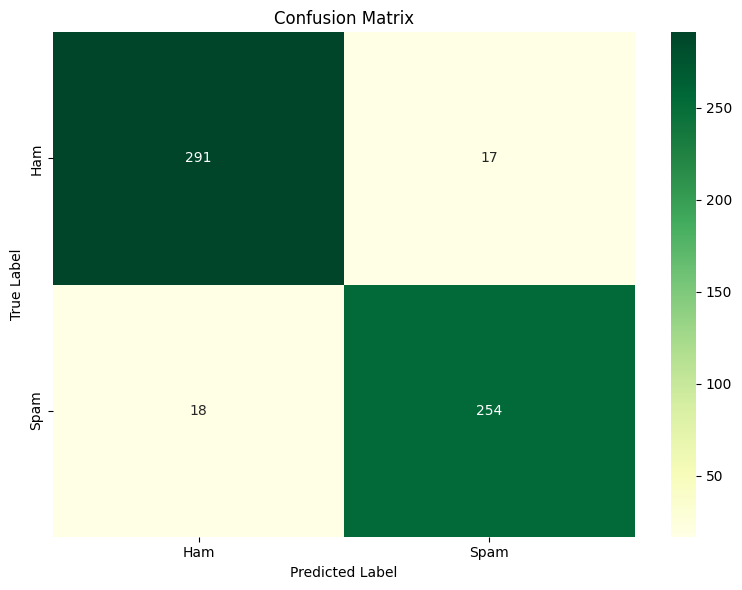


=== Feature Importance Analysis ===
Available importance types: dict_keys(['SUM_SCORE', 'INV_MEAN_MIN_DEPTH', 'NUM_AS_ROOT', 'MEAN_DECREASE_IN_ACCURACY', 'NUM_NODES', 'MEAN_DECREASE_IN_AP_1_VS_OTHERS', 'MEAN_DECREASE_IN_PRAUC_1_VS_OTHERS', 'MEAN_DECREASE_IN_AUC_1_VS_OTHERS'])


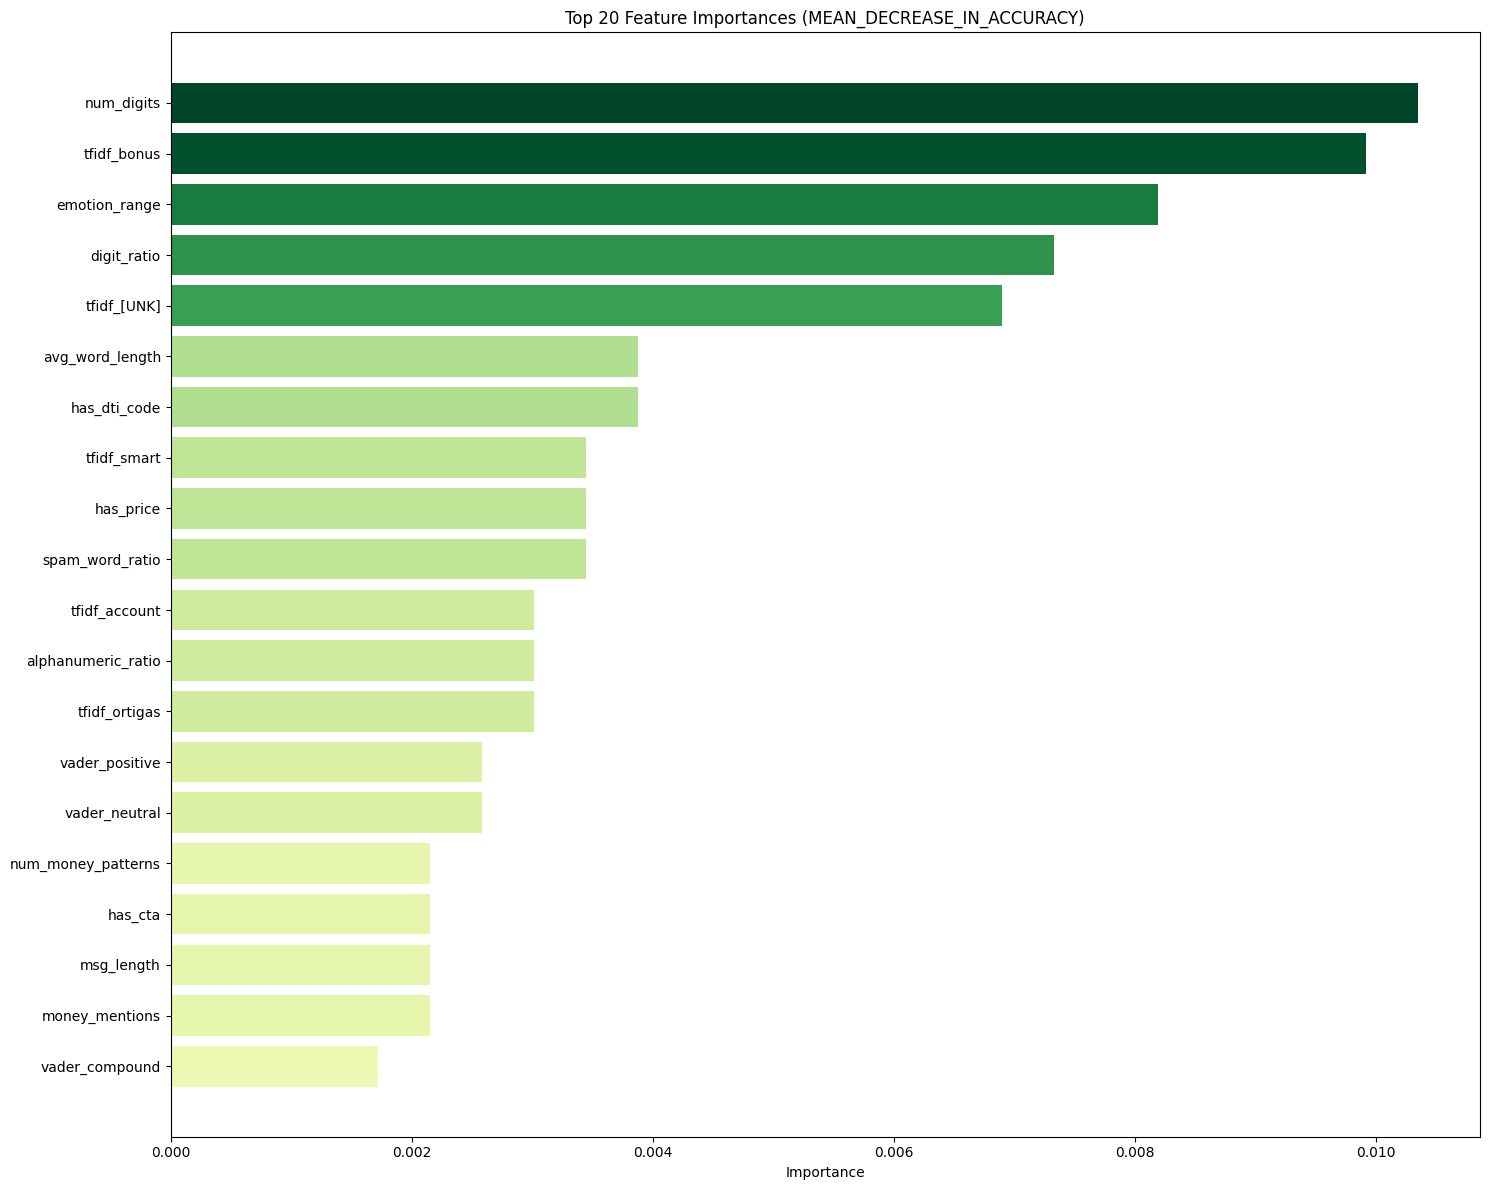

In [ ]:
CSV_FILE_PATH = "/content/drive/MyDrive/colab_mounted_files/cleaned-final-212-shuffled.csv"

# Train the model
spam_filter, results, importance = train_spam_filter(
    csv_file_path=CSV_FILE_PATH,
    test_size=0.2,
    num_trees=557,
    max_depth=-1
)

In [ ]:
spam_filter.model.describe()

In [ ]:
spam_filter.model.plot_tree() #428 535 557

In [ ]:
# Test on some new messages
print("\n" + "="*60)
print("Testing on New Messages")
print("="*60)

test_messages = [
"""Pamessage nako dahil Napili !tong number mo na makakuha ng E@SY SCATT3R at 7,777 cash or IPHONE 17 sa mismong GAMESLOT, hinihintay ko po ang chat mo. Addfriend po para mkita ko agad!! FBKO0- Alexcia Eunice ( naka white na Tshirt at may Eyeglasses sa Profile picture )""",
"""You received PHP7,045.95 in your Wallet from 747 Live. Your balance is PHP7045.95. Ref. No. 0aee060a7b2b.""",
"""SERVICE ADVISORY

There will be a scheduled maintenance activity in your area from OCTOBER 27 1AM to 5AM . You may experience degraded services for 2hrs & 30minutes. Please restart your modem after the activity. If the issue persists, visit https://m.me/PLDTHome to report a service issue. Thank you for your understanding.""",
"""FREE HEALTH INSURANCE on GCash with SMART!

Stay connected & protected when you subscribe to POWER ALL 149 now on GCash to get 7 days of 16 GB of shareable data + UNLI FB or UNLI TikTok + UNLI ALLNET CALLS & TEXTS + up to P30k accident coverage!

Load na sa GCash! T&Cs apply. DTI222782""",
"""Save more with Smart and Maya this payday weekend!

Get 10% CASHBACK when you subscribe to select POWER ALL promos via Maya from Sep 25-26.

For first time loaders in Maya, get an additional P100 CASHBACK when you purchase POWER ALL 99 or 149.

Don't have the app yet? Download and load now! DTI235901""",
"""1OO%WelcomeBouns+FreeSp#n
>>> tny.im/megaball
Megaball1casion. com
+SabongBonus. com
Best JiliBounsSite
Play JILI/S@bong/B@ccarat 8888GiftEveryDay"""
]

predictions = predict_new_messages(spam_filter, test_messages)


Testing on New Messages
Preparing features...
Extracting VADER sentiment features...
Extracting TF-IDF features...
Total features extracted: 3037
  - Base features: 31
  - Sentiment features: 6
  - TF-IDF features: 3000

=== Prediction Results ===

Message 1:
  Text: "Pamessage nako dahil Napili !tong number mo na makakuha ng E@SY SCATT3R at 7,777 cash or IPHONE 17 s..."
  Prediction: SPAM
  Spam Probability: 61.60%
  Confidence: 61.60%

Message 2:
  Text: "You received PHP7,045.95 in your Wallet from 747 Live. Your balance is PHP7045.95. Ref. No. 0aee060a..."
  Prediction: HAM
  Spam Probability: 3.30%
  Confidence: 96.70%

Message 3:
  Text: "SERVICE ADVISORY

There will be a scheduled maintenance activity in your area from OCTOBER 27 1AM to..."
  Prediction: HAM
  Spam Probability: 8.40%
  Confidence: 91.60%

Message 4:
  Text: "FREE HEALTH INSURANCE on GCash with SMART!

Stay connected & protected when you subscribe to POWER A..."
  Prediction: HAM
  Spam Probability: 1.60%
  Conf

In [ ]:
# import json
# import numpy as np
# import joblib

# print("Saving all model components...")

# # 1. Save the YDF model itself
# spam_filter.model.save("gubat_model_final")
# print("✅ YDF model saved to 'gubat_model_final'")

# # The TextVectorization layer holds the weights in its internal lookup layer
# idf_weights = spam_filter.tfidf_vectorizer._lookup_layer.idf_weights
# np.save('gubat_tfidf_idf_weights_final.npy', idf_weights)
# print("✅ TF-IDF IDF Weights saved to 'gubat_tfidf_idf_weights_final.npy'")

# # 2. Save the fitted StandardScaler
# joblib.dump(spam_filter.scaler, "gubat_scaler_final.joblib")
# print("✅ Scaler saved to 'gubat_scaler_final.joblib'")

# # 3. Save the TextVectorization layer's vocabulary
# # This is the "fitted" part of the text layer
# vocab = spam_filter.tfidf_vectorizer.get_vocabulary()
# with open('gubat_tfidf_vocab_final.json', 'w') as f:
#     json.dump(vocab, f)
# print(f"✅ TF-IDF vocabulary (size {len(vocab)}) saved to 'gubat_tfidf_vocab_final.json'")

# # 4. Save the final list of feature names (EXTREMELY IMPORTANT)
# # This ensures the order of columns is always correct
# feature_names = spam_filter.feature_names
# with open('gubat_feature_names_final.json', 'w') as f:
#     json.dump(feature_names, f)
# print(f"✅ Saved {len(feature_names)} feature names to 'gubat_feature_names_final.json'")

Saving all model components...
✅ YDF model saved to 'gubat_model_final'
✅ TF-IDF IDF Weights saved to 'gubat_tfidf_idf_weights_final.npy'
✅ Scaler saved to 'gubat_scaler_final.joblib'
✅ TF-IDF vocabulary (size 3000) saved to 'gubat_tfidf_vocab_final.json'
✅ Saved 3037 feature names to 'gubat_feature_names_final.json'


In [ ]:
# import pandas as pd
# import numpy as np
# from itertools import product
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# import time
# import json
# import os

# class SpamFilterTuner:
#     """
#     Hyperparameter tuner for EnhancedSMSSpamFilter
#     """

#     def __init__(self, spam_filter_class, csv_file_path, results_filepath='all_tuning_results.json'):
#         """
#         Initialize the tuner

#         Parameters:
#         -----------
#         spam_filter_class : class
#             The EnhancedSMSSpamFilter class (not an instance)
#         csv_file_path : str
#             Path to the training data CSV
#         results_filepath : str
#             Path to save all tuning results (will append to this file)
#         """
#         self.spam_filter_class = spam_filter_class
#         self.csv_file_path = csv_file_path
#         self.results_filepath = results_filepath
#         self.results = []

#         # Load existing results if the file exists
#         if os.path.exists(self.results_filepath):
#             try:
#                 with open(self.results_filepath, 'r') as f:
#                     existing_results = json.load(f)
#                     # Convert ngrams back to tuples if they were saved as strings
#                     for res in existing_results:
#                         if 'config' in res and 'ngrams' in res['config'] and isinstance(res['config']['ngrams'], str):
#                              # Assuming the string format is like "(1, 3)"
#                              try:
#                                  res['config']['ngrams'] = tuple(map(int, res['config']['ngrams'].strip('()').split(', ')))
#                              except:
#                                  # Handle cases where the string format might be unexpected
#                                  print(f"Warning: Could not parse ngrams string: {res['config']['ngrams']}")
#                                  pass # Keep as string or handle as appropriate
#                     self.results = existing_results
#                 print(f"Loaded {len(self.results)} existing results from {self.results_filepath}")
#             except Exception as e:
#                 print(f"Error loading existing results from {self.results_filepath}: {e}")
#                 self.results = []


#     def evaluate_config(self, config):
#         """
#         Train and evaluate a single configuration

#         Parameters:
#         -----------
#         config : dict
#             Dictionary with hyperparameters: tfidf_features, ngrams, num_trees, max_depth
#         """
#         print(f"\n{'='*60}")
#         print(f"Testing configuration:")
#         print(f"  TF-IDF Features: {config['tfidf_features']}")
#         print(f"  N-grams: {config['ngrams']}")
#         print(f"  Num Trees: {config['num_trees']}")
#         print(f"  Max Depth: {config['max_depth']}")
#         print(f"{'='*60}")

#         start_time = time.time()

#         try:
#             # Initialize model with current config

#             print(f"Loading data from: {self.csv_file_path}")
#             df = pd.read_csv(self.csv_file_path)

#             spam_filter = self.spam_filter_class(
#                 tfidf_features=config['tfidf_features'],
#             )

#             # Override ngrams in the vectorizer
#             spam_filter.tfidf_vectorizer = tf.keras.layers.TextVectorization(
#                 max_tokens=config['tfidf_features'],
#                 output_mode="tf_idf",
#                 ngrams=config['ngrams'],
#                 standardize=spam_filter.custom_standardization
#             )

#             # Prepare features
#             X = spam_filter.prepare_features(df['text'], fit_tfidf=True)
#             y = df['label']
#             # First split: separate test set
#             X_train, X_test, y_train, y_test = train_test_split(
#                 X, y,
#                 test_size=0.2,
#                 random_state=42,
#                 stratify=y
#             )

#             print(f"Training set: {len(X_train)} samples")
#             print(f"Test set: {len(X_test)} samples")

#             # Train model
#             spam_filter.train(
#                 X_train,
#                 y_train,
#                 num_trees=config['num_trees'],
#                 max_depth=config['max_depth'],
#                 verbose=False
#             )

#             # Evaluate on training set
#             predictions = spam_filter.predict(X_test)
#             probabilities = spam_filter.predict_proba(X_test)

#             # Calculate metrics
#             accuracy = accuracy_score(y_test, predictions)
#             precision = precision_score(y_test, predictions, average='weighted')
#             recall = recall_score(y_test, predictions, average='weighted')
#             f1 = f1_score(y_test, predictions, average='weighted')

#             training_time = time.time() - start_time

#             result = {
#                 'config': config.copy(),
#                 'accuracy': accuracy,
#                 'precision': precision,
#                 'recall': recall,
#                 'f1_score': f1,
#                 'training_time': training_time,
#                 'status': 'success'
#             }

#             print(f"\n✅ Results:")
#             print(f"  Accuracy:  {accuracy:.10f}")
#             print(f"  Precision: {precision:.10f}")
#             print(f"  Recall:    {recall:.10f}")
#             print(f"  F1 Score:  {f1:.10f}")
#             print(f"  Time:      {training_time:.4f}s")

#             return result

#         except Exception as e:
#             print(f"\n❌ Error: {str(e)}")
#             return {
#                 'config': config.copy(),
#                 'status': 'failed',
#                 'error': str(e)
#             }

#     def grid_search(self, param_grid, metric='f1_score'):
#         """
#         Perform grid search over hyperparameter space

#         Parameters:
#         -----------
#         param_grid : dict
#             Dictionary with lists of values for each hyperparameter
#             Example: {
#                 'tfidf_features': [500, 1000, 1500],
#                 'ngrams': [(1, 1), (1, 2), (1, 3)],
#                 'num_trees': [100, 150, 200],
#                 'max_depth': [8, 16, None]
#             }
#         metric : str
#             Metric to optimize ('accuracy', 'precision', 'recall', 'f1_score')
#         """
#         print("\n" + "="*60)
#         print("STARTING GRID SEARCH")
#         print("="*60)

#         # Generate all combinations
#         param_names = list(param_grid.keys())
#         param_values = list(param_grid.values())

#         all_combinations = list(product(*param_values))
#         total_combinations = len(all_combinations)

#         print(f"\nTotal configurations to test: {total_combinations}")
#         print(f"Optimizing for: {metric}")

#         # Test each combination
#         for idx, combination in enumerate(all_combinations, 1):
#             config = dict(zip(param_names, combination))
#             print(f"\n[{idx}/{total_combinations}]")

#             # Check if this config has already been run (based on loaded results)
#             config_already_run = any(
#                 r['config'] == config
#                 for r in self.results
#                 if 'config' in r
#             )

#             if config_already_run:
#                 print("Configuration already found in results, skipping...")
#                 continue

#             result = self.evaluate_config(config)
#             self.results.append(result)

#             # Save results after each iteration
#             self.save_all_results(self.results_filepath)


#         # Find best configuration
#         successful_results = [r for r in self.results if r['status'] == 'success']

#         if not successful_results:
#             print("\n❌ No successful configurations found!")
#             return None

#         best_result = max(successful_results, key=lambda x: x[metric])

#         print("\n" + "="*60)
#         print("GRID SEARCH COMPLETE")
#         print("="*60)
#         print(f"\n🏆 Best Configuration (by {metric}):")
#         print(f"  TF-IDF Features: {best_result['config']['tfidf_features']}")
#         print(f"  N-grams: {best_result['config']['ngrams']}")
#         print(f"  Num Trees: {best_result['config']['num_trees']}")
#         print(f"  Max Depth: {best_result['config']['max_depth']}")
#         print(f"\n  Metrics:")
#         print(f"    Accuracy:  {best_result['accuracy']:.4f}")
#         print(f"    Precision: {best_result['precision']:.4f}")
#         print(f"    Recall:    {best_result['recall']:.4f}")
#         print(f"    F1 Score:  {best_result['f1_score']:.4f}")
#         print(f"    Time:      {best_result['training_time']:.2f}s")

#         return best_result

#     def get_results_dataframe(self):
#         """
#         Convert results to a pandas DataFrame for analysis
#         """
#         if not self.results:
#             return pd.DataFrame()

#         # Flatten the nested config dict
#         flattened_results = []
#         for result in self.results:
#             if result['status'] == 'success':
#                 flat_result = result['config'].copy()
#                 flat_result.update({
#                     'accuracy': result['accuracy'],
#                     'precision': result['precision'],
#                     'recall': result['recall'],
#                     'f1_score': result['f1_score'],
#                     'training_time': result['training_time']
#                 })
#                 flattened_results.append(flat_result)

#         df = pd.DataFrame(flattened_results)
#         return df.sort_values('f1_score', ascending=False)

#     def save_all_results(self, filepath):
#         """
#         Save ALL tuning results (all iterations) to JSON file
#         """
#         # Convert tuples to strings for JSON serialization
#         results_copy = []
#         for result in self.results:
#             result_copy = result.copy()
#             if 'config' in result_copy and 'ngrams' in result_copy['config']:
#                 result_copy['config']['ngrams'] = str(result_copy['config']['ngrams'])
#             results_copy.append(result_copy)

#         with open(filepath, 'w') as f:
#             json.dump(results_copy, f, indent=2)
#         print(f"\n💾 All results saved to {filepath}")


#     def save_best_config(self, best_result, filepath='best_config.json'):
#         """
#         Save only the best configuration to a separate JSON file

#         Parameters:
#         -----------
#         best_result : dict
#             The best result dictionary from grid_search
#         filepath : str
#             Path to save the best config JSON
#         """
#         if best_result is None:
#             print("\n❌ No best result to save!")
#             return

#         # Convert tuples to strings for JSON serialization
#         best_result_copy = best_result.copy()
#         if 'config' in best_result_copy and 'ngrams' in best_result_copy['config']:
#             best_result_copy['config']['ngrams'] = str(best_result_copy['config']['ngrams'])

#         with open(filepath, 'w') as f:
#             json.dump(best_result_copy, f, indent=2)
#         print(f"🏆 Best config saved to {filepath}")


# # Example usage:
# # Initialize tuner
# tuner = SpamFilterTuner(EnhancedSMSSpamFilter, '/content/drive/MyDrive/colab_mounted_files/cleaned-final-212.csv')

# # Define parameter grid
# param_grid = {
#     'tfidf_features': [3000],
#     'ngrams': [1],
#     'num_trees': [428, 535, 557],
#     'max_depth': [-1],
# }

# # Run grid search
# best_config = tuner.grid_search(param_grid, metric='f1_score')

# # Save all iterations to one file (already happens in grid_search)
# # tuner.save_all_results('all_tuning_results.json')

# # Save best config to separate file
# tuner.save_best_config(best_config, 'best_config.json')

# # View all results
# results_df = tuner.get_results_dataframe()
# print(results_df.head(10))